In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib as mpl

plt.style.use('sty.mplstyle')

atomic_mass_unit = 1.6605e-27 # kg
MAr = 39.95*atomic_mass_unit # Mass of argon in atomic mass units

def Compute_Trident_Events_Uncertainties(convXsec, MD, Int_Flux, POT):
    # convXsec should be given in fb
    # MD should be given in tonnes
    # POT should be given in units of 10^{21}
    # Int_Flux should be given in nu/m^2/POT
    Uncertainty = np.zeros_like(convXsec)
    for i in range(len(convXsec)):
        for j in range(len(convXsec[i])):
            Uncertainty[i][j] = 100*np.abs( 1 - convXsec[i][j]/convXsec[i][0] )
    NumOfEvents = Int_Flux * convXsec * MD/MAr * POT
    NumOfEvents = 1e-19*NumOfEvents
    return NumOfEvents, Uncertainty

# MiniBooNE

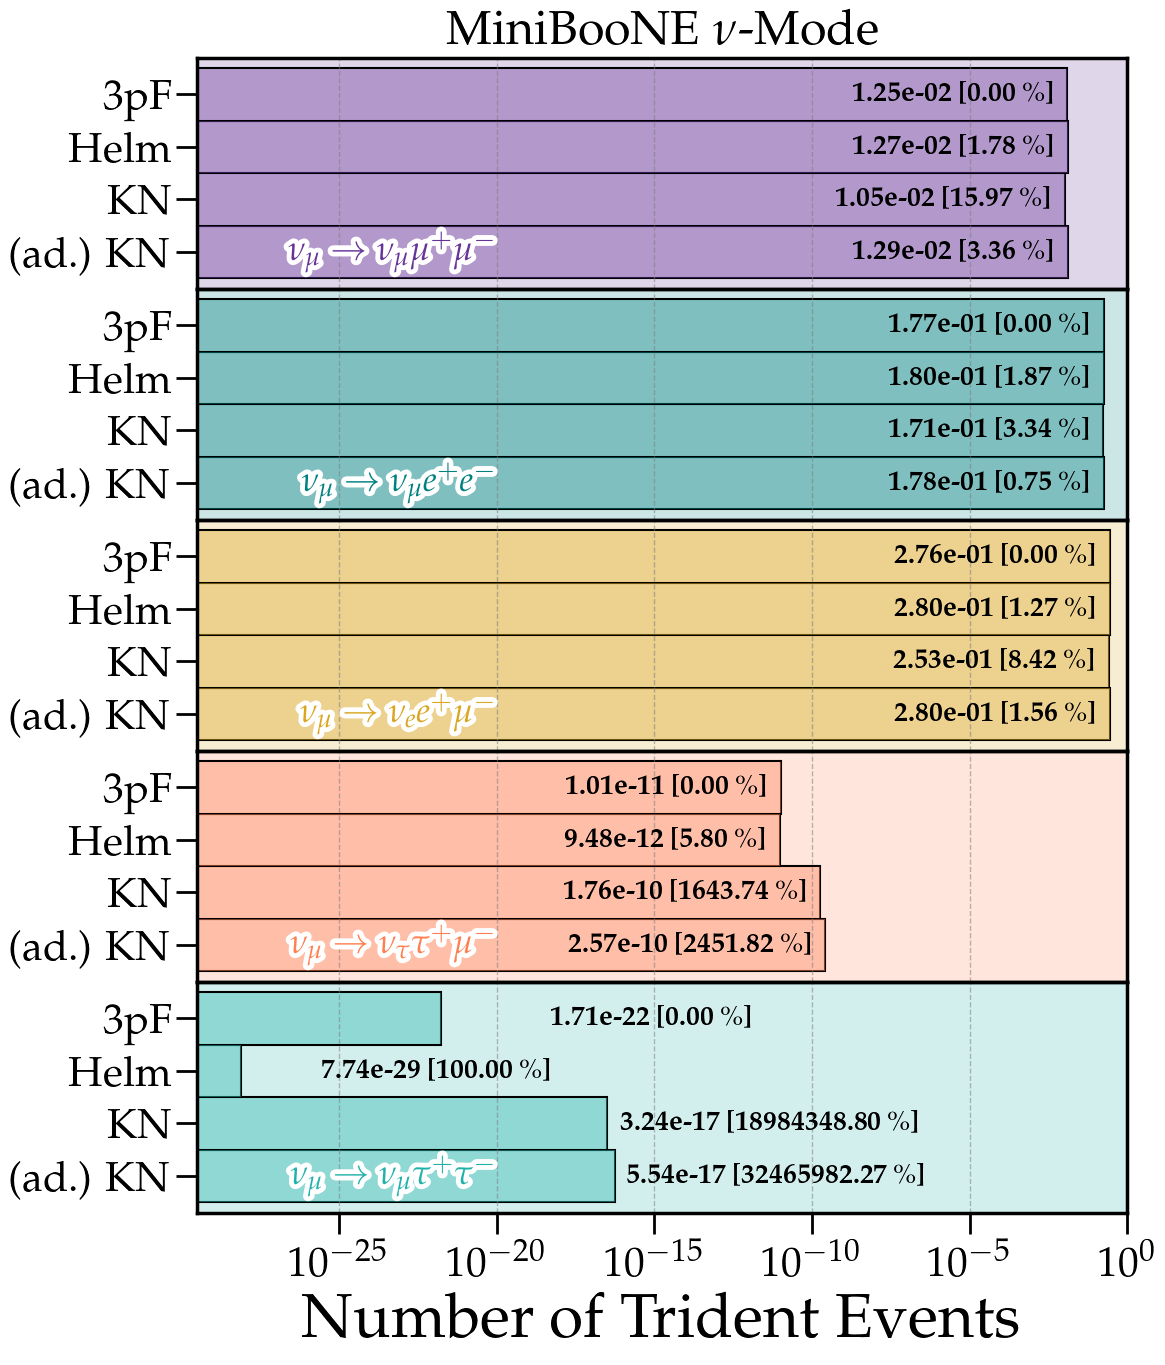

In [2]:
########################################################################################## 
##### Integrated Neutrino Flux (Neutrino Mode): 5.188231179736934e-06 m^-2 POT^-1 
########################################################################################## 
MD_MiniBooNE = 112
POT_MiniBooNE = 0.66
Total_Flux_MiniBooNE = 5.188231179736934e-06
ConvXsec_NuFlux_NuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_nuMode_MiniBooNE')
NumOfEvents_NuFlux_NuMode_MiniBooNE, Uncertainty_NuFlux_NuMode_MiniBooNE = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_NuMode_MiniBooNE, MD_MiniBooNE, Total_Flux_MiniBooNE, POT_MiniBooNE)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_NuMode_MiniBooNE)):
    data = NumOfEvents_NuFlux_NuMode_MiniBooNE[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.4, 0.4, 0.4, 0.4, 8e9]
for i in range(len(NumOfEvents_NuFlux_NuMode_MiniBooNE)):
    for j in range(len(NumOfEvents_NuFlux_NuMode_MiniBooNE[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_NuMode_MiniBooNE[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_NuMode_MiniBooNE[i][j], Uncertainty_NuFlux_NuMode_MiniBooNE[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-20, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'MiniBooNE $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(right=1)

plt.savefig(r'../Plots/Figures_PDF/EventsatMiniBooNE_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatMiniBooNE_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

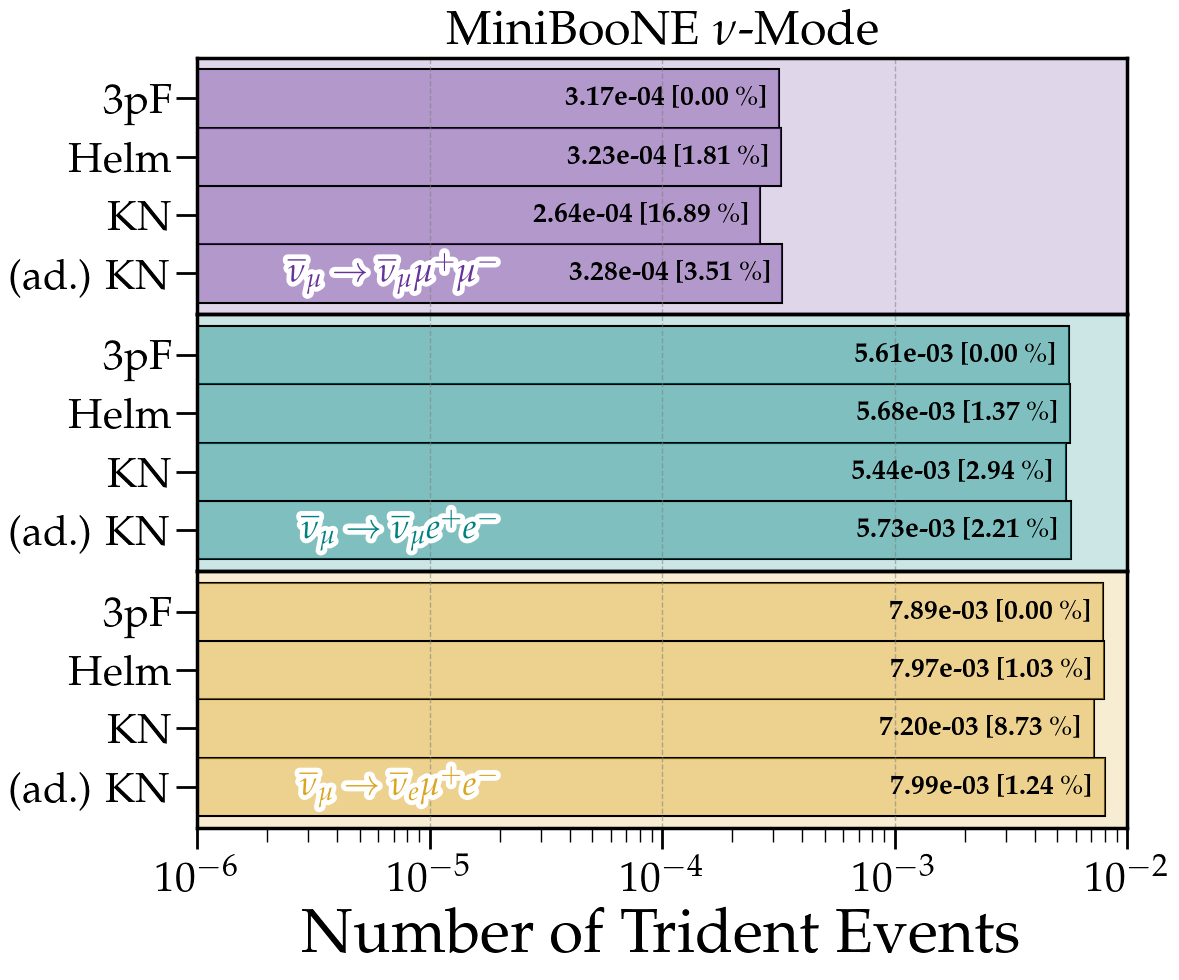

In [3]:
########################################################################################## 
##### Integrated Antineutrino Flux (Neutrino Mode): 3.205341386277867e-07 m^-2 POT^-1 
########################################################################################## 
MD_MiniBooNE = 112
POT_MiniBooNE = 0.66
Total_Flux_MiniBooNE = 3.205341386277867e-07
ConvXsec_AntiNuFlux_NuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_antinuflux_nuMode_MiniBooNE')
NumOfEvents_AntiNuFlux_NuMode_MiniBooNE, Uncertainty_AntiNuFlux_NuMode_MiniBooNE = Compute_Trident_Events_Uncertainties(ConvXsec_AntiNuFlux_NuMode_MiniBooNE, MD_MiniBooNE, Total_Flux_MiniBooNE, POT_MiniBooNE)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

for i in range(len(NumOfEvents_AntiNuFlux_NuMode_MiniBooNE)):
    data = NumOfEvents_AntiNuFlux_NuMode_MiniBooNE[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.9, 0.9, 0.9]
for i in range(len(NumOfEvents_AntiNuFlux_NuMode_MiniBooNE)):
    for j in range(len(NumOfEvents_AntiNuFlux_NuMode_MiniBooNE[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_AntiNuFlux_NuMode_MiniBooNE[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_AntiNuFlux_NuMode_MiniBooNE[i][j], Uncertainty_AntiNuFlux_NuMode_MiniBooNE[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(2e-5, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'MiniBooNE $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-6, right=1e-2)

plt.savefig(r'../Plots/Figures_PDF/EventsatMiniBooNE_AntiNuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatMiniBooNE_AntiNuFlux_NuMode.png', transparent=False, bbox_inches='tight')

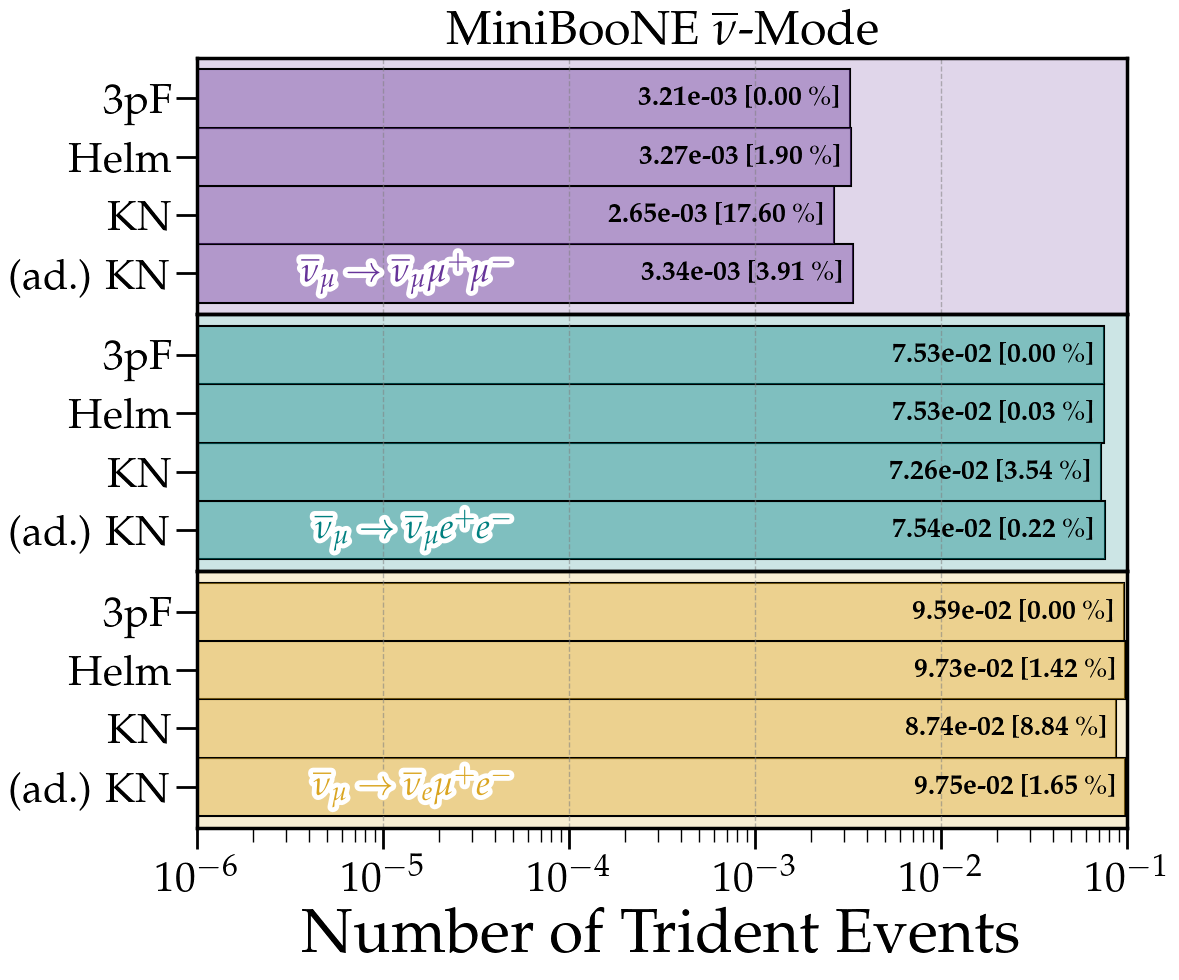

In [4]:
########################################################################################## 
##### Integrated Antineutrino Flux (Antineutrino Mode): 2.9249541426034934e-06 m^-2 POT^-1 
########################################################################################## 
MD_MiniBooNE = 112
POT_MiniBooNE = 0.66
Total_Flux_MiniBooNE = 2.9249541426034934e-06
ConvXsec_AntiNuFlux_AntiNuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_antinuflux_antinuMode_MiniBooNE')
NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE, Uncertainty_AntiNuFlux_AntiNuMode_MiniBooNE = Compute_Trident_Events_Uncertainties(ConvXsec_AntiNuFlux_AntiNuMode_MiniBooNE, MD_MiniBooNE, Total_Flux_MiniBooNE, POT_MiniBooNE)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

for i in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE)):
    data = NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.9, 0.9, 0.9]
for i in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE)):
    for j in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE[i][j], Uncertainty_AntiNuFlux_AntiNuMode_MiniBooNE[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(5e-5, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'MiniBooNE $\overline{\nu}$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-6, right=1e-1)

plt.savefig(r'../Plots/Figures_PDF/EventsatMiniBooNE_AntiNuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatMiniBooNE_AntiNuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

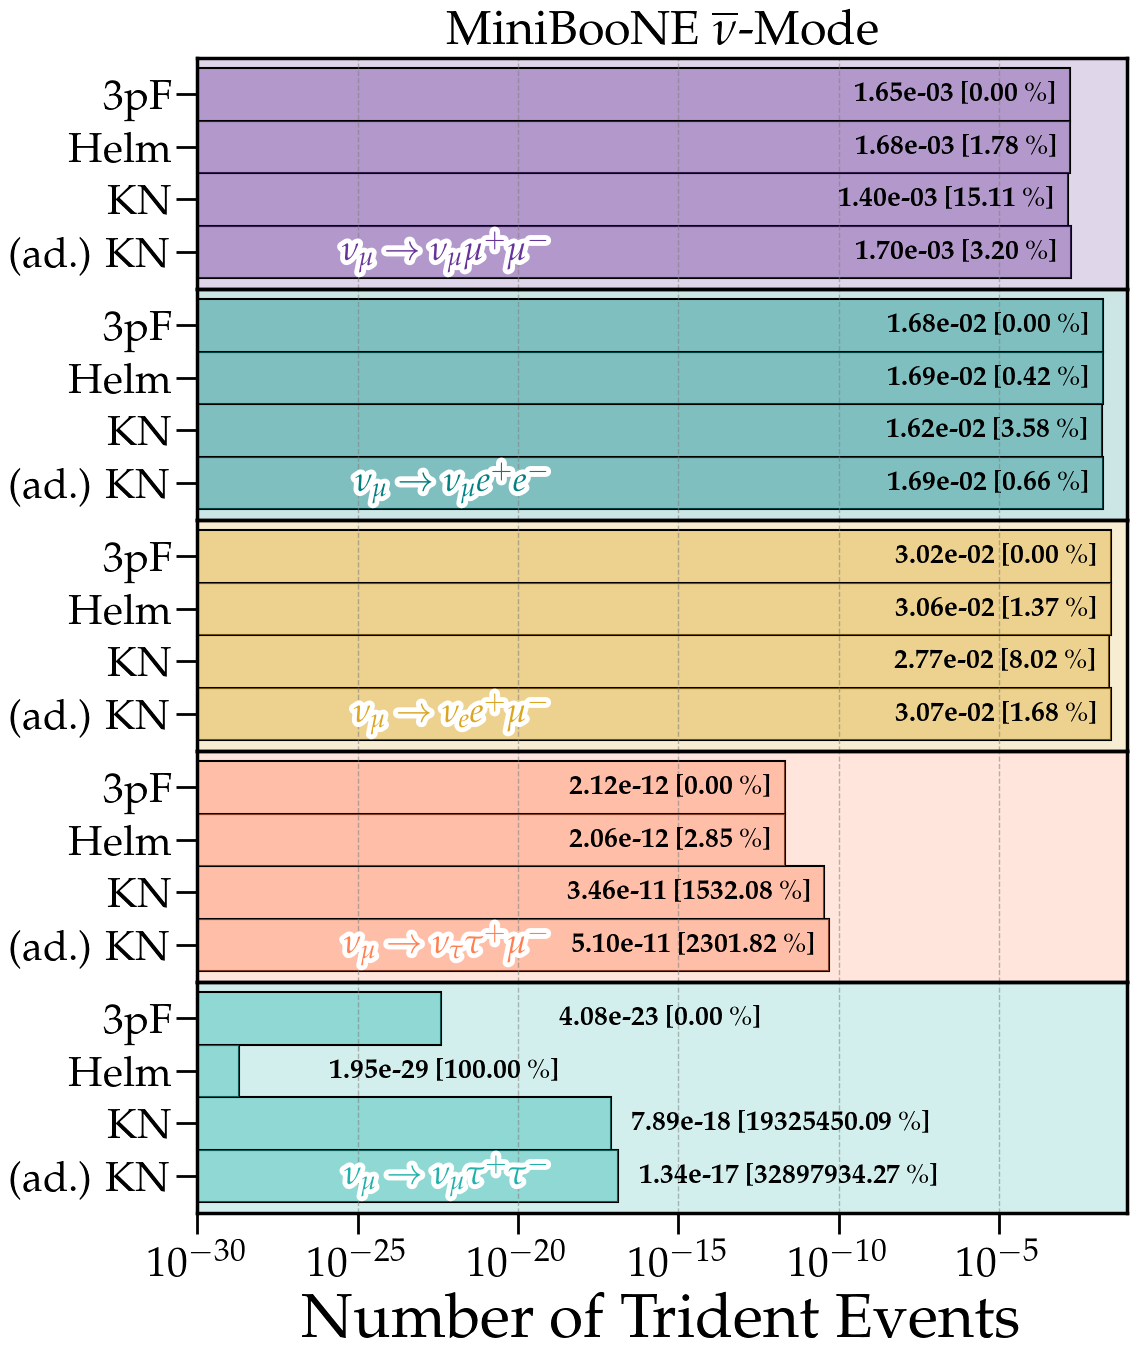

In [5]:
########################################################################################## 
##### Integrated Neutrino Flux (Antineutrino Mode): 5.365346615405332e-07 m^-2 POT^-1 
########################################################################################## 
MD_MiniBooNE = 112
POT_MiniBooNE = 0.66
Total_Flux_MiniBooNE = 5.365346615405332e-07
ConvXsec_NuFlux_AntiNuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_antinuMode_MiniBooNE')
NumOfEvents_NuFlux_AntiNuMode_MiniBooNE, Uncertainty_NuFlux_AntiNuMode_MiniBooNE = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_AntiNuMode_MiniBooNE, MD_MiniBooNE, Total_Flux_MiniBooNE, POT_MiniBooNE)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_AntiNuMode_MiniBooNE)):
    data = NumOfEvents_NuFlux_AntiNuMode_MiniBooNE[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.4, 0.4, 0.4, 0.4, 1e10]
for i in range(len(NumOfEvents_NuFlux_AntiNuMode_MiniBooNE)):
    for j in range(len(NumOfEvents_NuFlux_AntiNuMode_MiniBooNE[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_AntiNuMode_MiniBooNE[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_AntiNuMode_MiniBooNE[i][j], Uncertainty_NuFlux_AntiNuMode_MiniBooNE[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-19, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'MiniBooNE $\overline{\nu}$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-30, right=1e-1)

plt.savefig(r'../Plots/Figures_PDF/EventsatMiniBooNE_NuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatMiniBooNE_NuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

# SBND

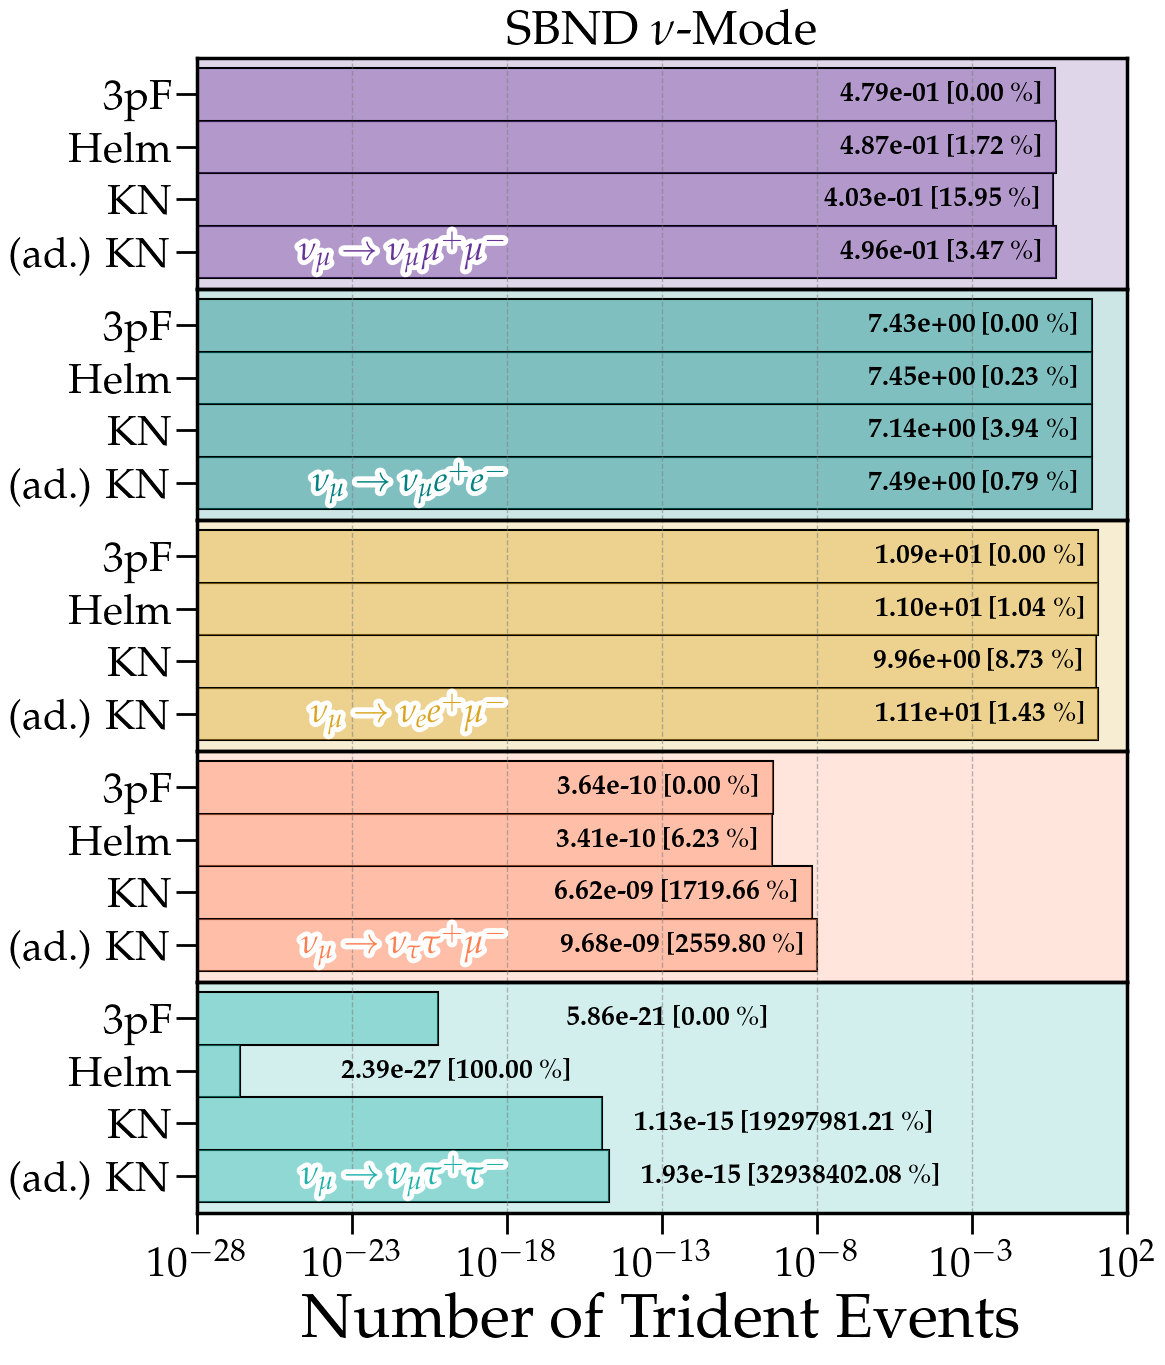

In [6]:
########################################################################################## 
##### Integrated Neutrino Flux (Neutrino Mode): 0.00016114069432666668 m^-2 POT^-1 
########################################################################################## 
MD_SBND = 112
POT_SBND = 1
Total_Flux_SBND = 0.00016114069432666668
ConvXsec_NuFlux_NuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_nuMode_SBND')
NumOfEvents_NuFlux_NuMode_SBND, Uncertainty_NuFlux_NuMode_SBND = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_NuMode_SBND, MD_SBND, Total_Flux_SBND, POT_SBND)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_NuMode_SBND)):
    data = NumOfEvents_NuFlux_NuMode_SBND[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.4, 0.4, 0.4, 0.4, 5e10]
for i in range(len(NumOfEvents_NuFlux_NuMode_SBND)):
    for j in range(len(NumOfEvents_NuFlux_NuMode_SBND[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_NuMode_SBND[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_NuMode_SBND[i][j], Uncertainty_NuFlux_NuMode_SBND[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-18, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'SBND $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-28, right=100)

plt.savefig(r'../Plots/Figures_PDF/EventsatSBND_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatSBND_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

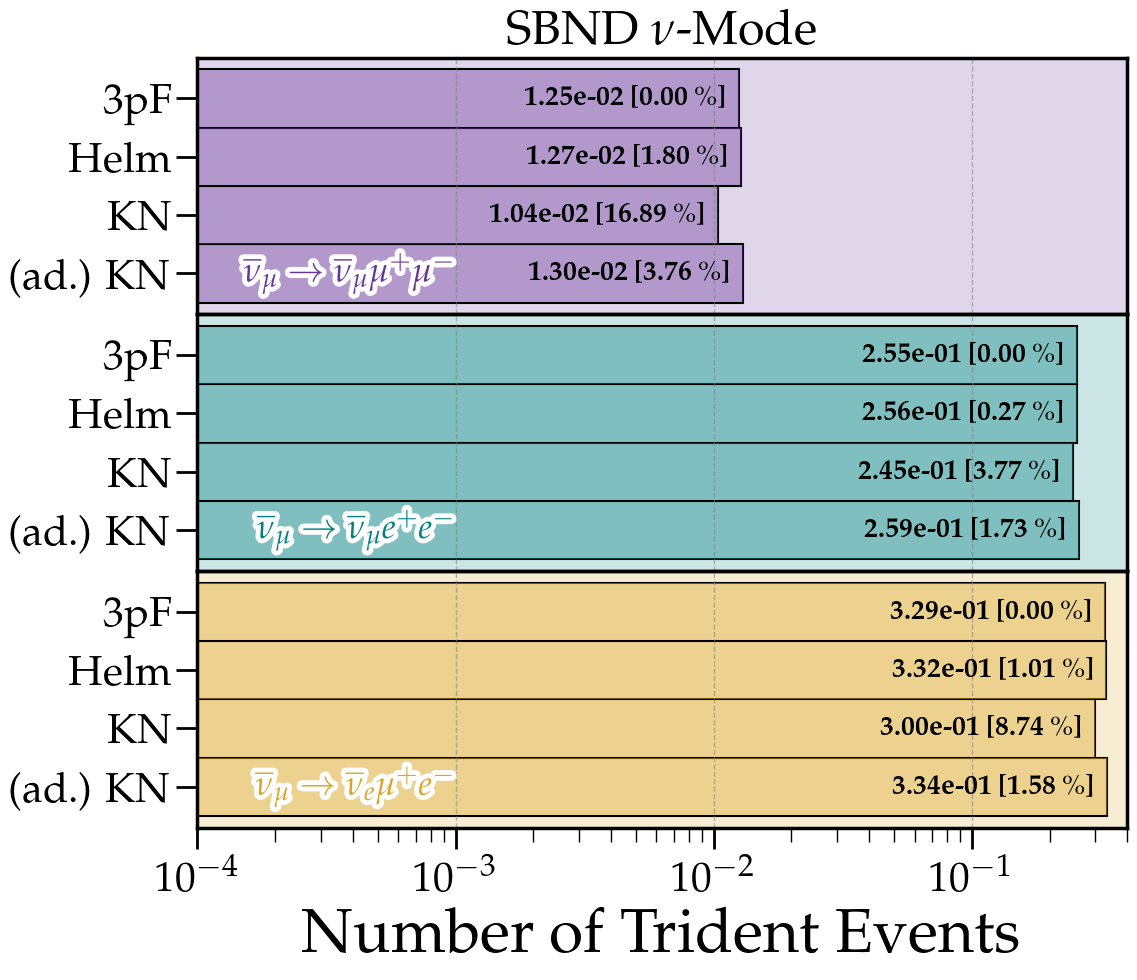

In [7]:
########################################################################################## 
##### Integrated Antineutrino Flux (Neutrino Mode): 1.1709089422666665e-05 m^-2 POT^-1 
########################################################################################## 
MD_SBND = 112
POT_SBND = 1
Total_Flux_SBND = 1.1709089422666665e-05
ConvXsec_AntiNuFlux_NuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_antinuflux_nuMode_SBND')
NumOfEvents_AntiNuFlux_NuMode_SBND, Uncertainty_AntiNuFlux_NuMode_SBND = Compute_Trident_Events_Uncertainties(ConvXsec_AntiNuFlux_NuMode_SBND, MD_SBND, Total_Flux_SBND, POT_SBND)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

for i in range(len(NumOfEvents_AntiNuFlux_NuMode_SBND)):
    data = NumOfEvents_AntiNuFlux_NuMode_SBND[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.9, 0.9, 0.9]
for i in range(len(NumOfEvents_AntiNuFlux_NuMode_SBND)):
    for j in range(len(NumOfEvents_AntiNuFlux_NuMode_SBND[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_AntiNuFlux_NuMode_SBND[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_AntiNuFlux_NuMode_SBND[i][j], Uncertainty_AntiNuFlux_NuMode_SBND[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-3, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'SBND $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-4, right=0.4)

plt.savefig(r'../Plots/Figures_PDF/EventsatSBND_AntiNuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatSBND_AntiNuFlux_NuMode.png', transparent=False, bbox_inches='tight')

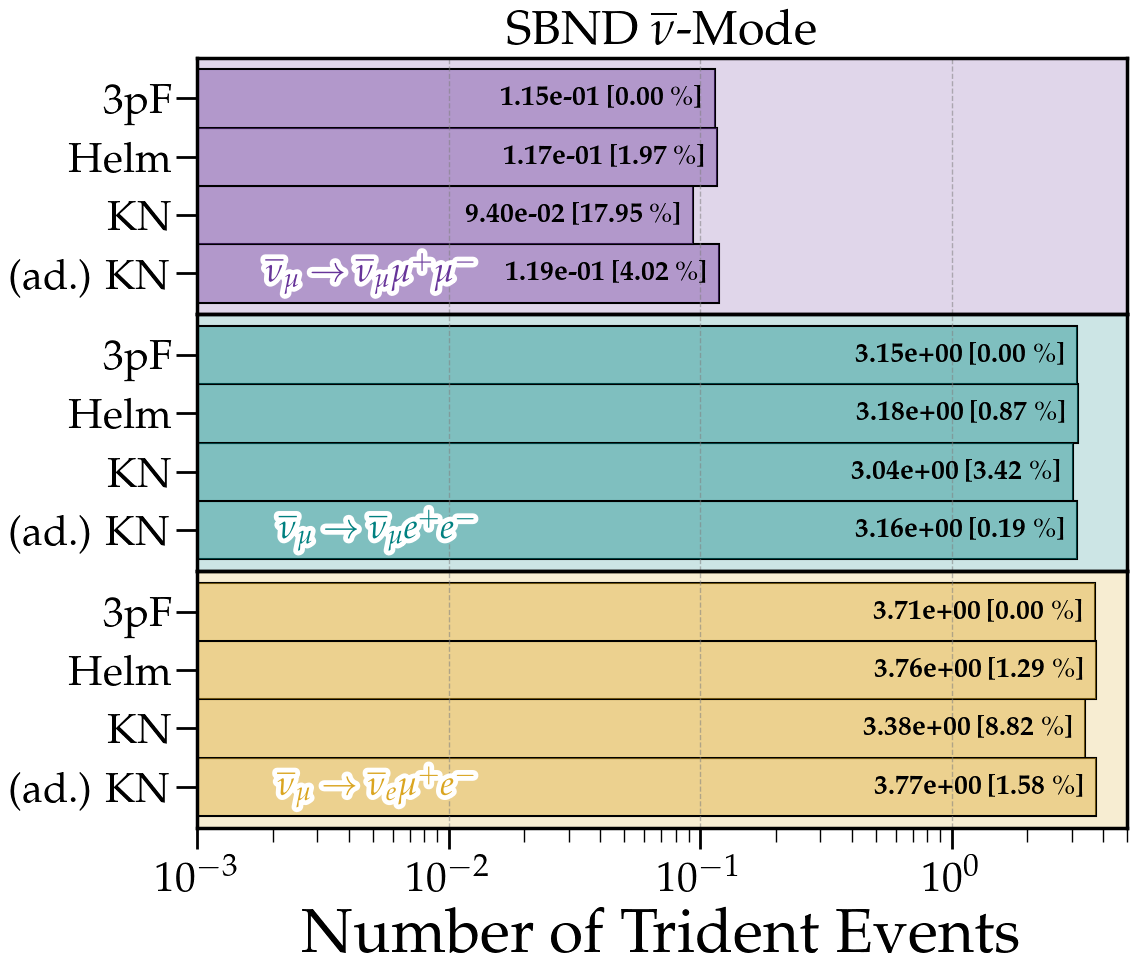

In [8]:
########################################################################################## 
##### Integrated Antineutrino Flux (Antineutrino Mode): 8.782506499594861e-05 m^-2 POT^-1 
########################################################################################## 
MD_SBND = 112
POT_SBND = 1
Total_Flux_SBND = 8.782506499594861e-05
ConvXsec_AntiNuFlux_AntiNuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_antinuflux_antinuMode_SBND')
NumOfEvents_AntiNuFlux_AntiNuMode_SBND, Uncertainty_AntiNuFlux_AntiNuMode_SBND = Compute_Trident_Events_Uncertainties(ConvXsec_AntiNuFlux_AntiNuMode_SBND, MD_SBND, Total_Flux_SBND, POT_SBND)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

for i in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_SBND)):
    data = NumOfEvents_AntiNuFlux_AntiNuMode_SBND[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.9, 0.9, 0.9]
for i in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_SBND)):
    for j in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_SBND[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_AntiNuFlux_AntiNuMode_SBND[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_AntiNuFlux_AntiNuMode_SBND[i][j], Uncertainty_AntiNuFlux_AntiNuMode_SBND[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1.3e-2, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'SBND $\overline{\nu}$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-3, right=5)

plt.savefig(r'../Plots/Figures_PDF/EventsatSBND_AntiNuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatSBND_AntiNuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

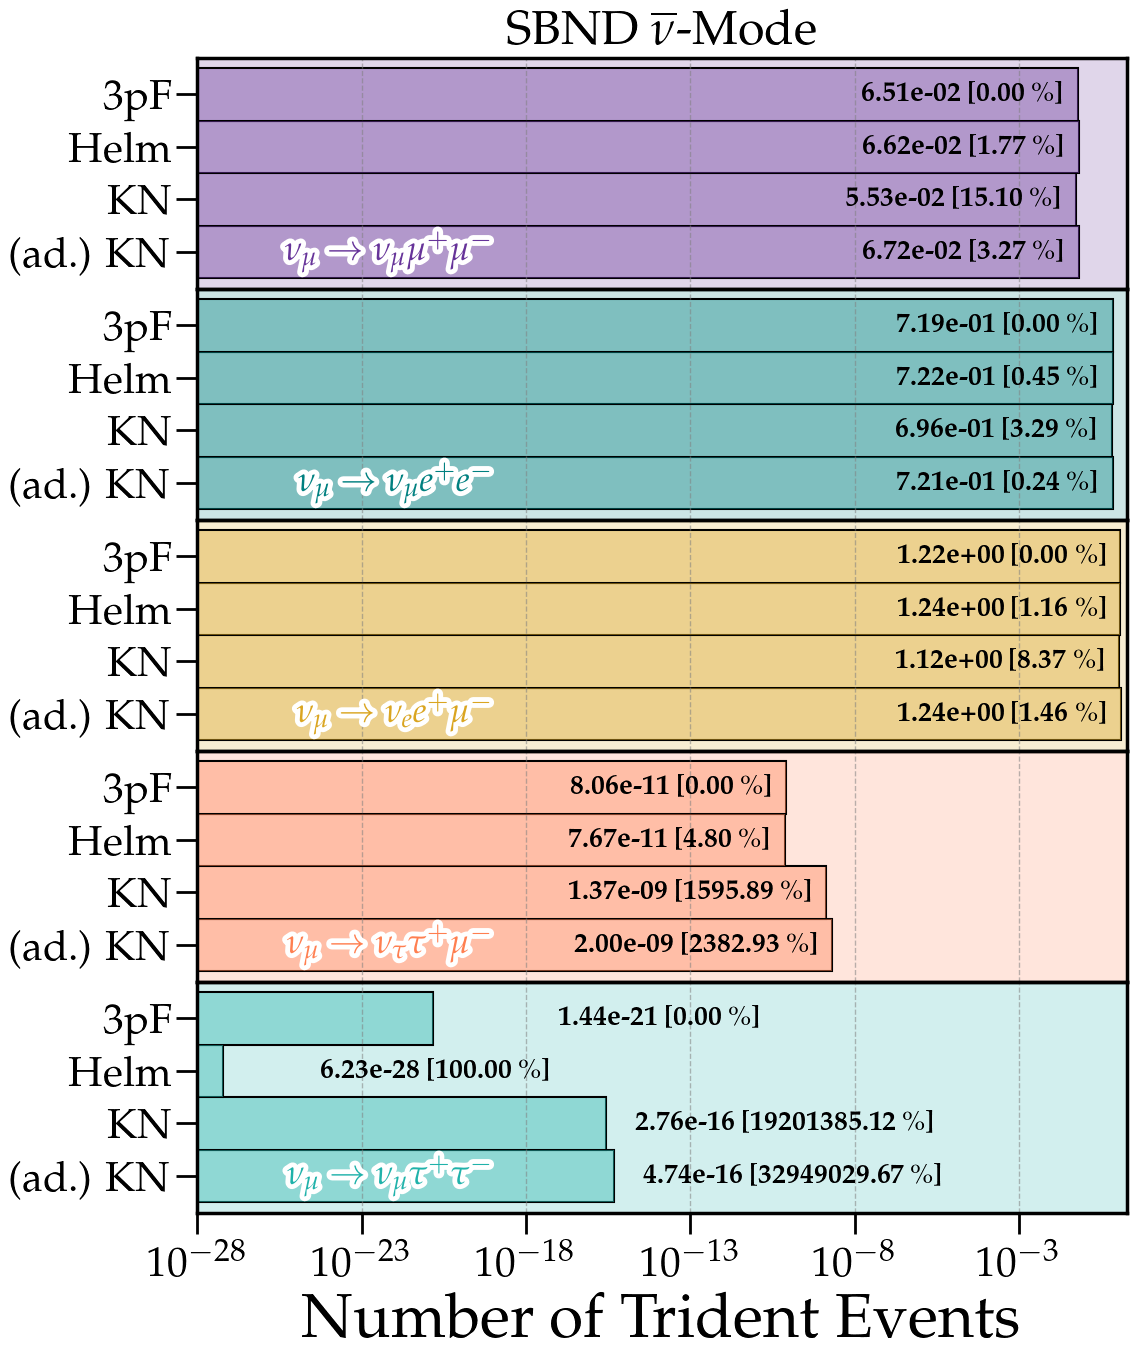

In [9]:
########################################################################################## 
##### Integrated Neutrino Flux (Antineutrino Mode): 1.5891932893480667e-05 m^-2 POT^-1 
########################################################################################## 
MD_SBND = 112
POT_SBND = 1
Total_Flux_SBND = 1.5891932893480667e-05
ConvXsec_NuFlux_AntiNuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_antinuMode_SBND')
NumOfEvents_NuFlux_AntiNuMode_SBND, Uncertainty_NuFlux_AntiNuMode_SBND = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_AntiNuMode_SBND, MD_SBND, Total_Flux_SBND, POT_SBND)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_AntiNuMode_SBND)):
    data = NumOfEvents_NuFlux_AntiNuMode_SBND[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.4, 0.4, 0.4, 0.4, 1e10]
for i in range(len(NumOfEvents_NuFlux_AntiNuMode_SBND)):
    for j in range(len(NumOfEvents_NuFlux_AntiNuMode_SBND[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_AntiNuMode_SBND[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_AntiNuMode_SBND[i][j], Uncertainty_NuFlux_AntiNuMode_SBND[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-19, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'SBND $\overline{\nu}$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-28, right=2)

plt.savefig(r'../Plots/Figures_PDF/EventsatSBND_NuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatSBND_NuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

# DUNE Std CP

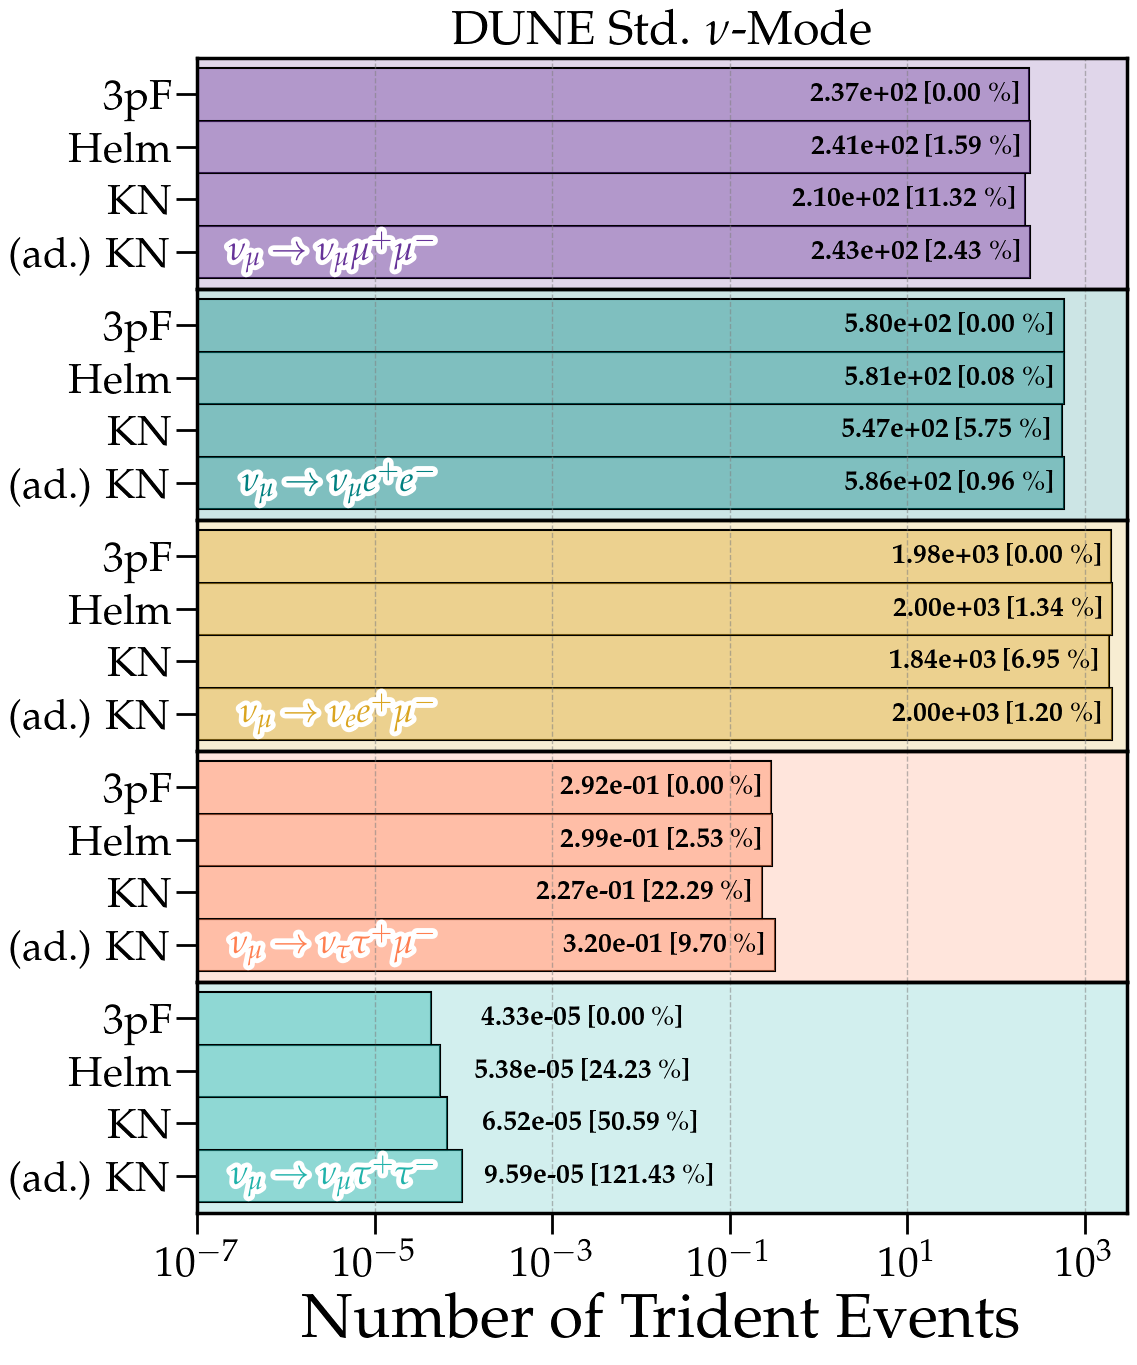

In [30]:
########################################################################################## 
##### Integrated Neutrino Flux (Neutrino Mode): 0.0010438734424042 m^-2 POT^-1 
########################################################################################## 
MD_DUNEStd = 67
POT_DUNEStd = 3.3
Total_Flux_DUNEStd = 0.0010438734424042
ConvXsec_NuFlux_NuMode_DUNEStd = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_nuMode_DUNEStd')
NumOfEvents_NuFlux_NuMode_DUNEStd, Uncertainty_NuFlux_NuMode_DUNEStd = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_NuMode_DUNEStd, MD_DUNEStd, Total_Flux_DUNEStd, POT_DUNEStd)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_NuMode_DUNEStd)):
    data = NumOfEvents_NuFlux_NuMode_DUNEStd[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.8, 0.8, 0.8, 0.8, 7e2]
for i in range(len(NumOfEvents_NuFlux_NuMode_DUNEStd)):
    for j in range(len(NumOfEvents_NuFlux_NuMode_DUNEStd[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_NuMode_DUNEStd[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_NuMode_DUNEStd[i][j], Uncertainty_NuFlux_NuMode_DUNEStd[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(5e-5, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'DUNE Std. $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-7, right=3e3)

plt.savefig(r'../Plots/Figures_PDF/EventsatDUNEStd_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatDUNEStd_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

# DUNE Tau OPT

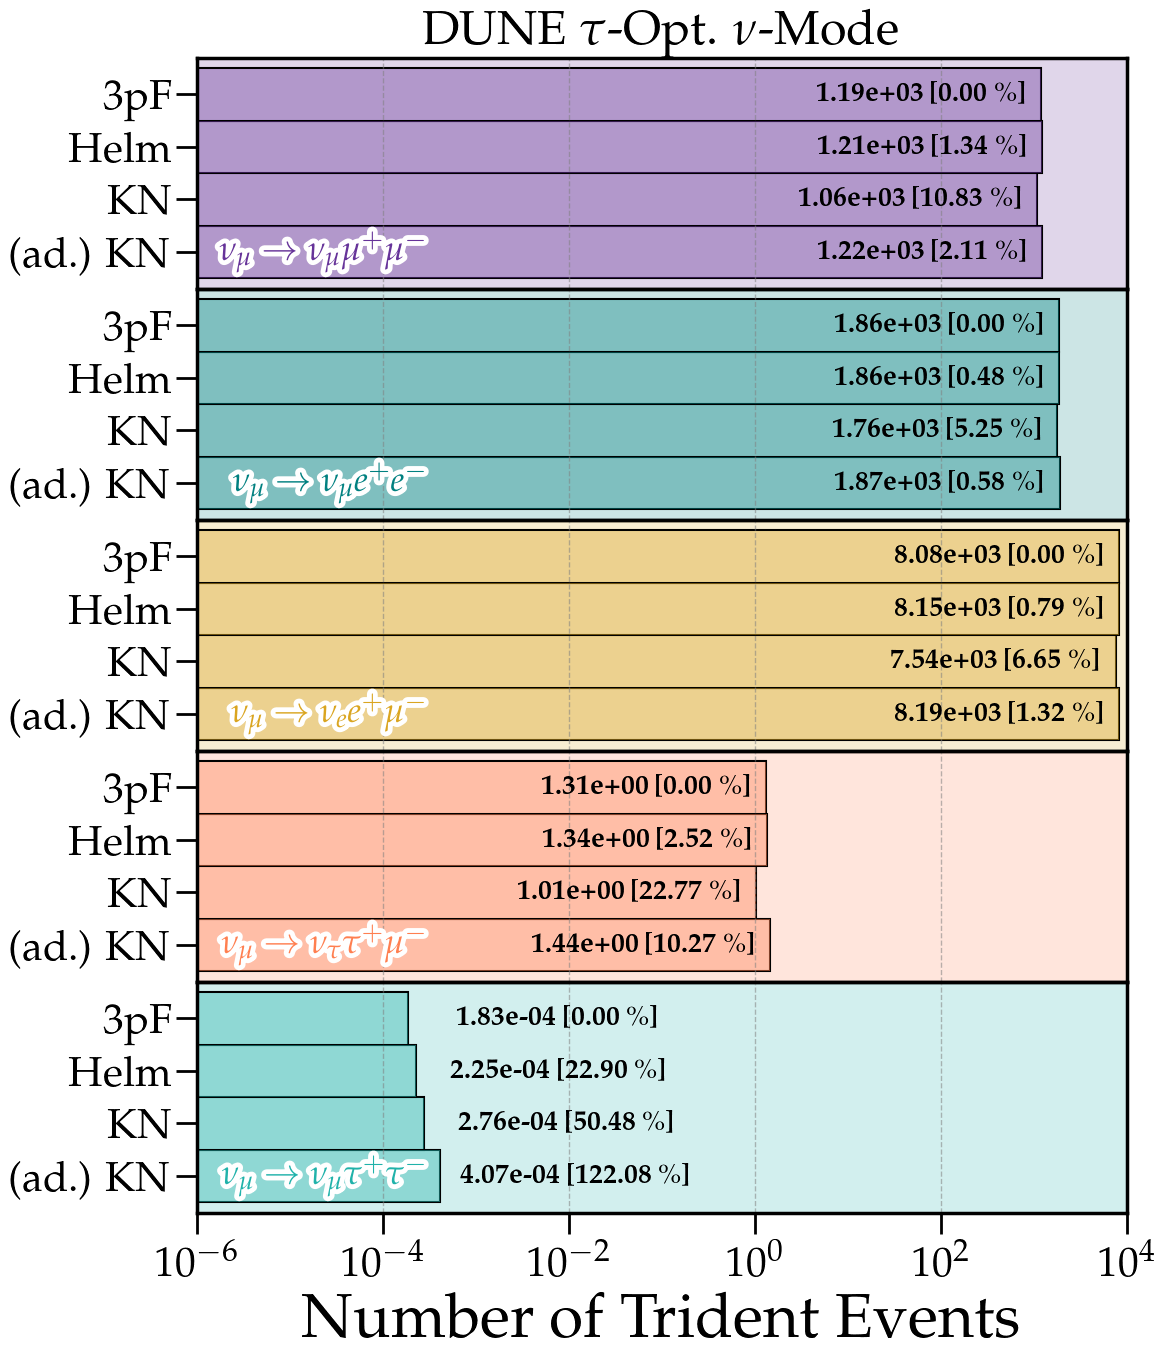

In [31]:
########################################################################################## 
##### Integrated Neutrino Flux (Neutrino Mode): 0.0011485658077633335 m^-2 POT^-1 
########################################################################################## 
MD_DUNETauOpt = 67
POT_DUNETauOpt = 3.3
Total_Flux_DUNETauOpt = 0.0011485658077633335
ConvXsec_NuFlux_NuMode_DUNETauOpt = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_nuMode_DUNETauOpt')
NumOfEvents_NuFlux_NuMode_DUNETauOpt, Uncertainty_NuFlux_NuMode_DUNETauOpt = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_NuMode_DUNETauOpt, MD_DUNETauOpt, Total_Flux_DUNETauOpt, POT_DUNETauOpt)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,15))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_NuMode_DUNETauOpt)):
    data = NumOfEvents_NuFlux_NuMode_DUNETauOpt[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.7, 0.7, 0.7, 0.7, 5e2]
for i in range(len(NumOfEvents_NuFlux_NuMode_DUNETauOpt)):
    for j in range(len(NumOfEvents_NuFlux_NuMode_DUNETauOpt[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_NuMode_DUNETauOpt[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_NuMode_DUNETauOpt[i][j], Uncertainty_NuFlux_NuMode_DUNETauOpt[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(3e-4, 0, Processes[i], fontsize=25, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=7, foreground='w', alpha=1), pe.Normal()])

ax[0].set_title(r'DUNE $\tau$-Opt. $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-6, right=1e4)

plt.savefig(r'../Plots/Figures_PDF/EventsatDUNETauOpt_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatDUNETauOpt_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')